# Python Lesson 52: Descriptive Statistics and Anscombe's Quartet

**Concept page:** `wiki/concepts/descriptive-statistics-and-anscombe.md` · **Area:** statistics

**You will be able to:**
- compute mean, variance, correlation and fitted line
- see identical statistics hide different shapes
- always plot first

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. The quartet (values from Anscombe, 1973)

In [2]:
x123=np.array([10,8,13,9,11,14,6,4,12,7,5.])
Y={"I":[8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68],
   "II":[9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74],
   "III":[7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]}
x4=np.array([8,8,8,8,8,8,8,19,8,8,8.]); y4=np.array([6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89])
sets={"I":(x123,np.array(Y["I"])),"II":(x123,np.array(Y["II"])),"III":(x123,np.array(Y["III"])),"IV":(x4,y4)}
for k,(x,y) in sets.items():
    a,b=np.polyfit(x,y,1); print(k, round(x.mean(),2),round(y.mean(),2),round(y.var(ddof=1),2),round(np.corrcoef(x,y)[0,1],3),f"y={b:.2f}+{a:.2f}x")

I 9.0 7.5 4.13 0.816 y=3.00+0.50x
II 9.0 7.5 4.13 0.816 y=3.00+0.50x
III 9.0 7.5 4.12 0.816 y=3.00+0.50x
IV 9.0 7.5 4.12 0.817 y=3.00+0.50x


## 2. Plot them

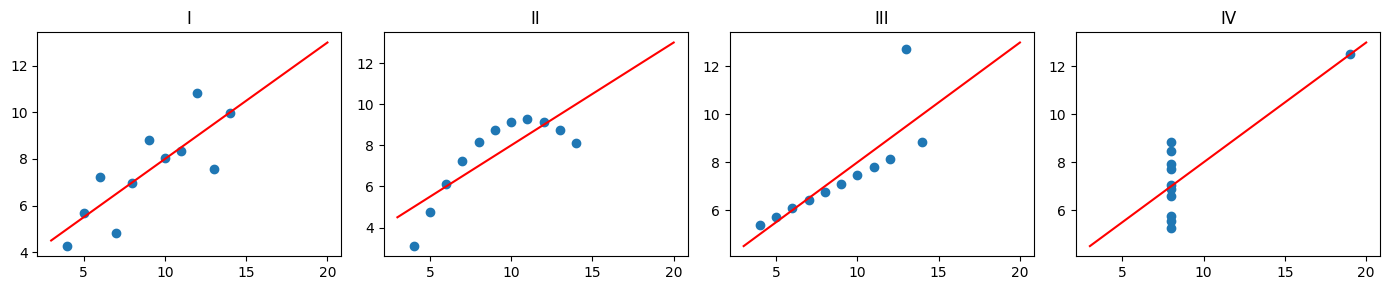

In [3]:
fig,axs=plt.subplots(1,4,figsize=(14,3))
for ax,(k,(x,y)) in zip(axs,sets.items()):
    ax.scatter(x,y); xs=np.linspace(3,20,10); a,b=np.polyfit(x,y,1); ax.plot(xs,b+a*xs,'r'); ax.set_title(k)
plt.tight_layout(); plt.show()

## 3. Cross-check against the course data file (if available)

In [4]:
import os,pandas as pd
p="data/df_anscombe.csv"
if os.path.exists(p): print(pd.read_csv(p).head())
else: print("course data file not found (fine)")

      x     y  group
0  10.0  8.04      1
1   8.0  6.95      1
2  13.0  7.58      1
3   9.0  8.81      1
4  11.0  8.33      1


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 basic ch. 5 fits a least-squares line through data; Anscombe shows why you must look at the scatter plot (ពពកចំណុចទិន្នន័យ) first.

In [5]:
print(np.polyfit(*sets['I'],1))

[0.5001 3.0001]


**Grade 8 statistics (ch. 10):** mean, median and mode straight from a frequency table, without expanding the data.

In [6]:
x=np.arange(1,9); f=np.array([11,79,82,67,20,25,11,5])    # 300 families, children per family
mean=(x*f).sum()/f.sum()
cum=np.cumsum(f); median=x[np.argmax(cum>=(f.sum()+1)/2)]   # position (n+1)/2 falls in this row (n even: both middle positions land here)
mode=x[f.argmax()]
print(mean,median,mode,cum)
assert (mean,median)==(3.5,3) and f.sum()==300

3.5 3 3 [ 11  90 172 239 259 284 295 300]


**Grade 10 statistics (vol. 2, ch. 7):** ungrouped vs grouped mean/median/mode on the textbook's 45 maths scores. Grouping with class midpoints loses a little accuracy.

In [7]:
from collections import Counter
scores=[15,29,32,43,46,47,48,52,52,53,54,60,60,61,63,64,64,66,66,69,72,72,72,73,75,75,76,79,79,80,80,81,81,81,81,83,83,87,87,89,90,91,91,93,94]
mid=np.arange(20,100,10); f=np.histogram(scores,bins=np.arange(15,100,10))[0]
print("freq",f.tolist())
print("mean",np.mean(scores),"grouped",(mid*f).sum()/f.sum())
print("median",np.median(scores),"mode",Counter(scores).most_common(1)[0][0])
F=np.cumsum(f); k=int(np.argmax(F>=f.sum()/2)); lo=15+10*k
Me=lo+(f.sum()/2-(F[k-1] if k else 0))/f[k]*10
print("grouped median (interpolated)",round(Me,2))
assert abs(np.mean(scores)-68.64)<0.01 and abs((mid*f).sum()/f.sum()-68.44)<0.01

freq [1, 2, 1, 7, 6, 7, 13, 8]
mean 68.64444444444445 grouped 68.44444444444444
median 72.0 mode 81
grouped median (interpolated) 72.86


**Grade 8 robustness (pp. 135-136):** one extreme value moves the mean but not the median or mode.

In [8]:
d=[1,2,2,2,3,3,4,9,10]
print(np.mean(d),np.median(d),Counter(d).most_common(1)[0][0])
d2=d[:-1]+[100]; print(np.mean(d2),np.median(d2))   # mean jumps, median unchanged
assert np.median(d)==np.median(d2)==3

4.0 3.0 2
14.0 3.0


## Exercises

**Exercise 1.** Show all four correlations are within 0.002 of 0.816.

In [9]:
# your code here

**Exercise 2.** Compute the residual standard deviation for each set; are they equal?

In [10]:
# your code here

## Solutions
*(Try the exercises first!)*

In [11]:
# Solution 1
assert all(abs(np.corrcoef(x,y)[0,1]-0.816)<0.002 for x,y in sets.values())

In [12]:
# Solution 2
print({k:round(float(np.std(y-np.polyval(np.polyfit(x,y,1),x),ddof=2)),2) for k,(x,y) in sets.items()})

{'I': 1.24, 'II': 1.24, 'III': 1.24, 'IV': 1.24}
